In [22]:
hhi_report.to_csv(
    "../reports/hhi_report.csv",
    index=False
)

# Advanced Analytics Insights

1. VaR and CVaR analysis shows which funds have higher downside risk during market fluctuations.

2. Funds with higher Sharpe Ratio provide better risk-adjusted returns compared to other schemes.

3. Investor cohort analysis shows newer investor groups and their contribution to total investment.

4. SIP continuity analysis identifies investors with gaps above 35 days as at-risk investors.

5. HHI concentration analysis highlights funds with concentrated portfolios and higher sector dependency.

In [23]:
hhi_report = hhi.merge(
    fund[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code"
)

hhi_report.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [24]:
hhi = (
    holdings
    .groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x/100)**2).sum())
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [25]:
import pandas as pd

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [26]:
sip["status"] = np.where(
sip.gap_days > 35,
"at-risk",
"regular"
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,first_year,gap_days,status
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN,regular
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0,at-risk
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN,regular
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0,at-risk
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0,at-risk


In [27]:
sip = sip.sort_values(
["investor_id","transaction_date"]
)

sip["gap_days"] = (
sip.groupby("investor_id")
.transaction_date
.diff()
.dt.days
)

In [28]:
sip = transactions[
    transactions.transaction_type=="SIP"
]

In [29]:
cohort = transactions.groupby(
    "first_year"
).agg(
    avg_sip=("amount_inr","mean"),
    total_invested=("amount_inr","sum")
)

cohort

,avg_sip,total_invested
first_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [30]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["first_year"] = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

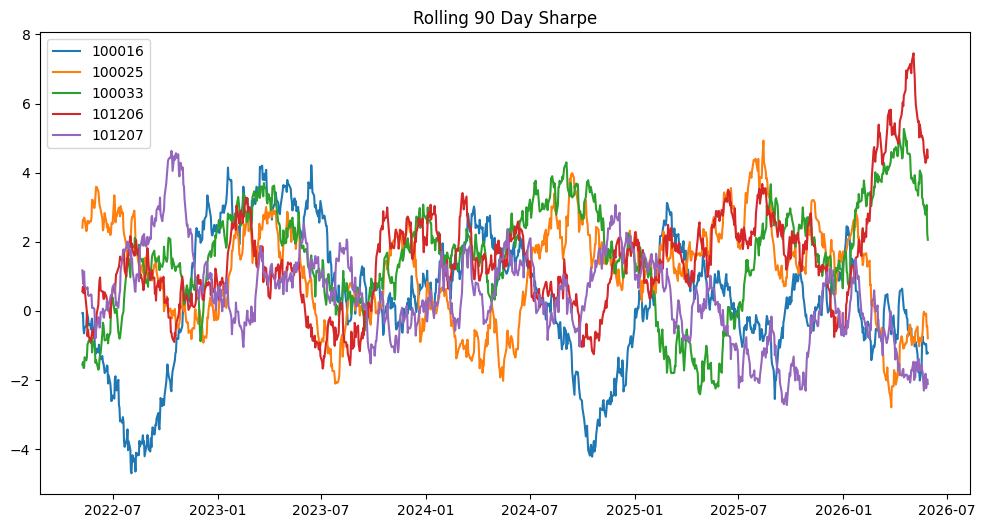

In [31]:
top5 = nav["amfi_code"].unique()[:5]


plt.figure(figsize=(12,6))

for fund_id in top5:

    temp = nav[
        nav.amfi_code == fund_id
    ]

    plt.plot(
        temp.date,
        temp.rolling_sharpe,
        label=fund_id
    )


plt.legend()
plt.title("Rolling 90 Day Sharpe")
plt.savefig(
"../reports/charts/rolling_sharpe_chart.png"
)

plt.show()

In [32]:
nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")
    ["daily_return"]
    .rolling(90)
    .mean()
    /
    nav.groupby("amfi_code")
    ["daily_return"]
    .rolling(90)
    .std()
    * np.sqrt(252)
).reset_index(level=0,drop=True)

In [33]:
nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")["daily_return"]
    .rolling(90)
    .mean()
    /
    nav.groupby("amfi_code")["daily_return"]
    .rolling(90)
    .std()
    * np.sqrt(252)
).reset_index(level=0, drop=True)

nav.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [34]:
var_report.to_csv(
"../reports/var_cvar_report.csv",
index=False
)

In [35]:
def calculate_var(x):

    var = np.percentile(
        x.dropna(),
        5
    )

    cvar = x[x <= var].mean()

    return pd.Series({
        "VaR_95":var,
        "CVaR_95":cvar
    })


var_report = (
    nav.groupby("amfi_code")
    ["daily_return"]
    .apply(calculate_var)
    .reset_index()
)

var_report.head()

,amfi_code,level_1,daily_return
0,100016,VaR_95,-0.014364
1,100016,CVaR_95,-0.018060
2,100025,VaR_95,-0.003793
3,100025,CVaR_95,-0.004994
4,100033,VaR_95,-0.019034


In [36]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [37]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

In [38]:
import os

print(os.listdir("../data/processed"))

['investor_transactions_clean.csv', 'nav_history_clean.csv', 'scheme_performance_clean.csv']


In [39]:
import pandas as pd

nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

fund = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

transactions = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(nav.head())
print(fund.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    S

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns